<h1>
Spotify song energy classifier <br>
Code for Logistic Regression and Randon Forest
</h1>

In [15]:
import pandas as pd
file_path = '/content/spotify_songs.csv'
df = pd.read_csv(file_path)

In [16]:
std_dev_energy = df['energy'].std()
mean_energy = df['energy'].mean()
median_energy = df['energy'].median()

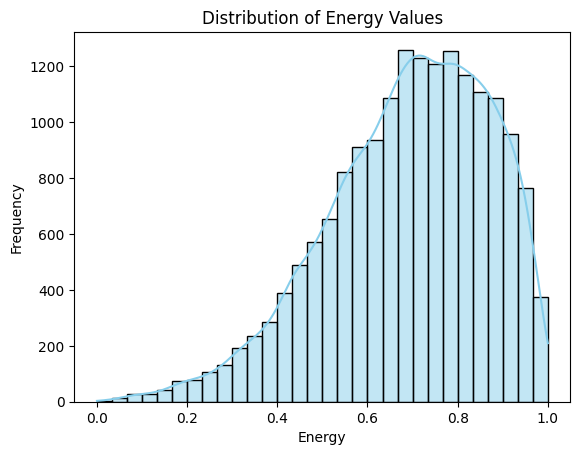

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['energy'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Energy Values')
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.show()

In [18]:
# Print the results
print(f"Mean of 'energy' column: {mean_energy}")
print(f"Median of 'energy' column: {median_energy}")
print(f"Standard Deviation of 'energy' column: {std_dev_energy}")


Mean of 'energy' column: 0.6916237978486011
Median of 'energy' column: 0.713
Standard Deviation of 'energy' column: 0.18007012163889488


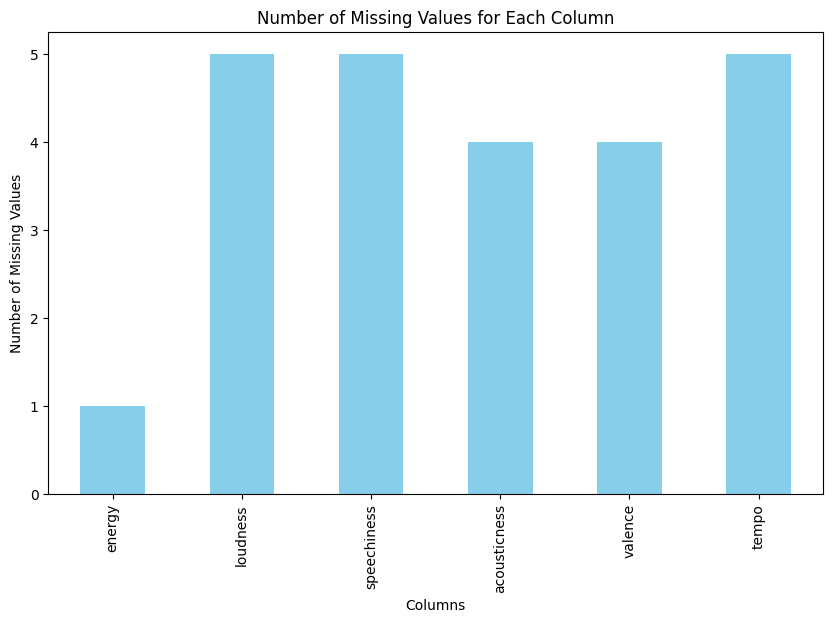

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Specifying the columns, we want to include on the x-axis
selected_columns = ['energy', 'loudness', 'speechiness', 'acousticness', 'valence', 'tempo']

# Count the number of missing values in each specified column
missing_values = df[selected_columns].isnull().sum()

# Plot the bar chart for missing values
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar', color='skyblue')
plt.title('Number of Missing Values for Each Column')
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.show()





<h1>
Logistic Regression
</h1>




Accuracy: 0.7505727376861397

Confusion Matrix:
[[1141  552]
 [ 319 1480]]

Classification Report:
              precision    recall  f1-score   support

       False       0.78      0.67      0.72      1693
        True       0.73      0.82      0.77      1799

    accuracy                           0.75      3492
   macro avg       0.75      0.75      0.75      3492
weighted avg       0.75      0.75      0.75      3492



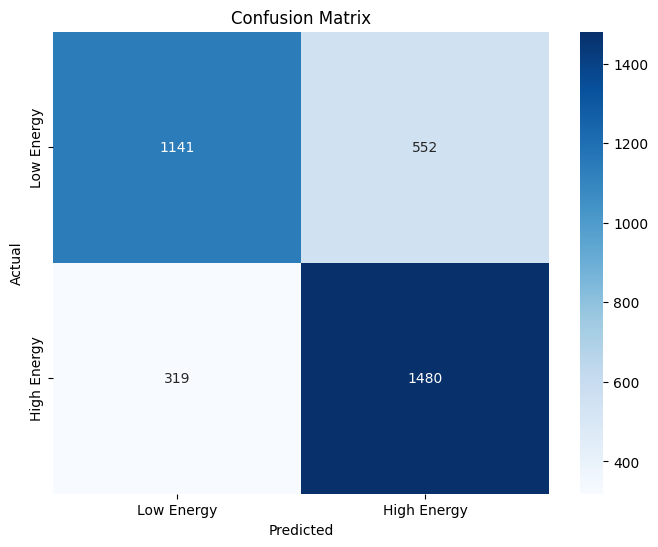

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the threshold for high and low energy
df['energy_category'] = df['energy'] >= 0.7

# Handling missing values
df.dropna(inplace=True)

# Selection of features and target variable
features = df[['loudness', 'speechiness', 'acousticness', 'valence', 'tempo']]
target = df['energy_category']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Min-Max Scaling for specific columns
min_max_scaler = MinMaxScaler()
columns_to_normalize = ['loudness', 'speechiness', 'acousticness', 'tempo']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_normalize] = min_max_scaler.fit_transform(X_train[columns_to_normalize])
X_test_scaled[columns_to_normalize] = min_max_scaler.transform(X_test[columns_to_normalize])

# Create a logistic regression model
model = LogisticRegression()

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
predictions = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)
classification_rep = classification_report(y_test, predictions)

# Print the results
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_rep)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Low Energy', 'High Energy'], yticklabels=['Low Energy', 'High Energy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


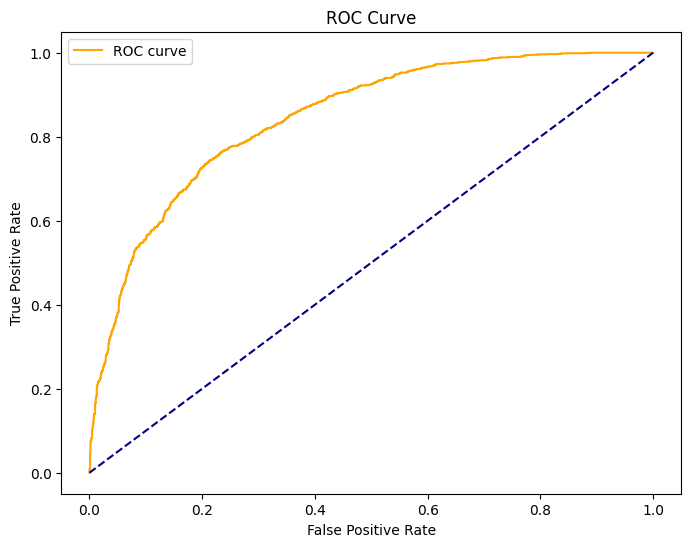

AUC: 0.84434944004791


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Calculate AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)


The AUC, or Area Under the Curve, is a metric used to evaluate the performance of a binary classification model. AUC is derived from the Receiver Operating Characteristic (ROC) curve, which plots the true positive rate (sensitivity) against the false positive rate (1 - specificity) at various threshold settings.
An AUC of 0.84434944004791 implies the following:

*   The value is close to 1, which indicates a good model performance. The closer the AUC is to 1, the better the model is at distinguishing between the two classes.
*   An AUC of 0.84 suggests that there is an 84.43% chance that the model will be able to distinguish between a randomly chosen positive instance and a randomly chosen negative instance.


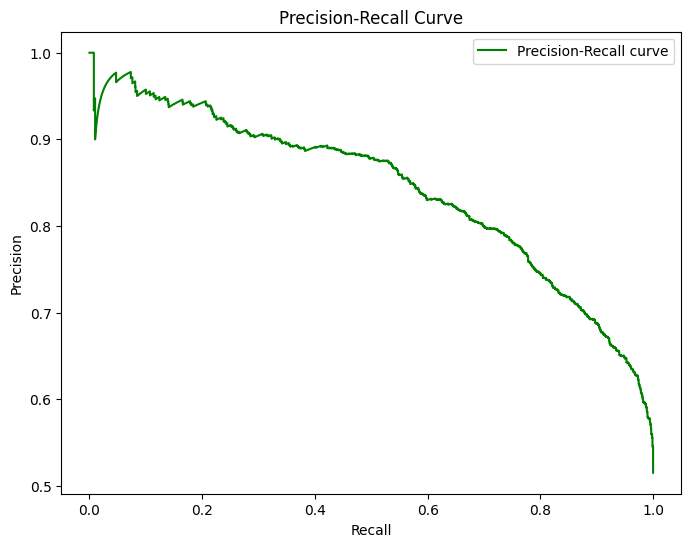

Average Precision: 0.8422128741299482


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute precision-recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Calculate Average Precision
average_precision = average_precision_score(y_test, y_prob)
print("Average Precision:", average_precision)


The Average Precision (AP) score of 0.8422128741299482 indicates that the model has a high level of precision across different levels of recall. This means that when the model predicts an instance as positive, it is correct about 84.22% of the time on average. This is a strong performance, especially in tasks where the precision of the positive predictions is important.

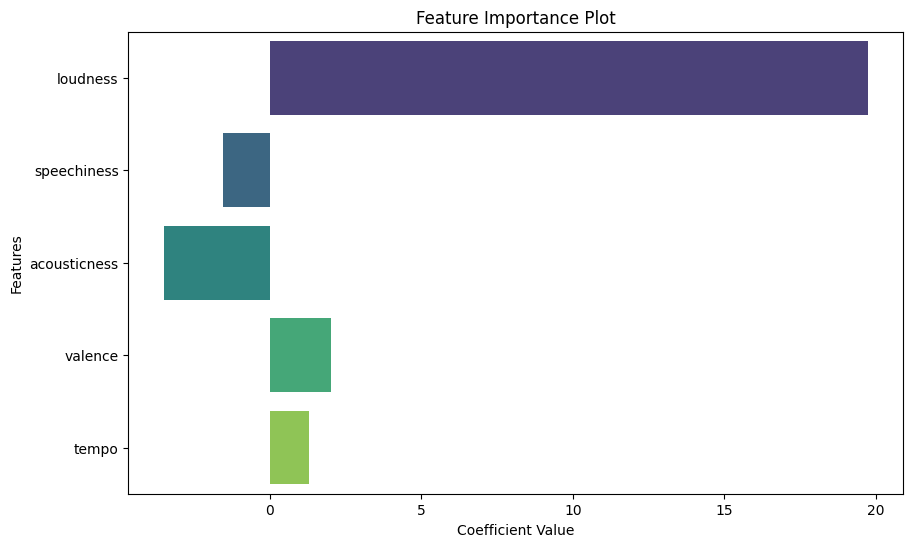

In [26]:
# Get feature coefficients from the trained model
feature_coefficients = model.coef_[0]

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_coefficients, y=features.columns, palette='viridis')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importance Plot')
plt.show()


In logistic regression, the sign and magnitude of the coefficients can be interpreted as follows:

*  Positive Coefficients
: Features with positive coefficients increase the log-odds of the outcome being 'high energy' and thus increase the probability of the 'high' class.
*  Negative Coefficients
: Features with negative coefficients decrease the log-odds of the outcome being 'high energy' and thus decrease the probability of the 'high' class.

The presence of negative values in the graph suggests that some features are negatively associated with the probability of an energy being classified as high. This means that as these feature values increase, the likelihood of the energy being classified as high decreases.


<h1>
Random Forest
</h1>


Accuracy: 0.8433074463225217

Confusion Matrix:
[[2385  534]
 [ 495 3153]]

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.82      0.82      2919
        True       0.86      0.86      0.86      3648

    accuracy                           0.84      6567
   macro avg       0.84      0.84      0.84      6567
weighted avg       0.84      0.84      0.84      6567



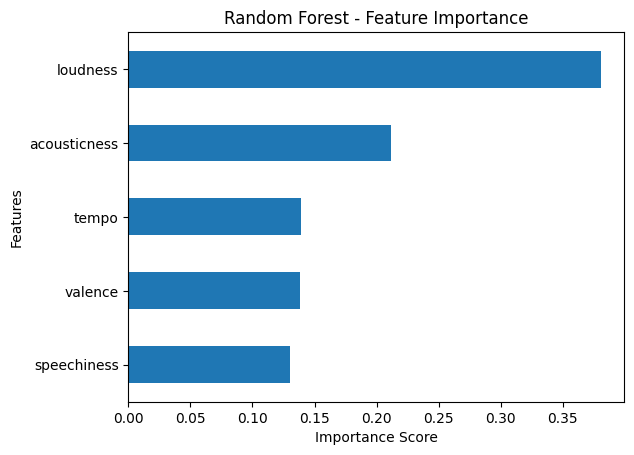

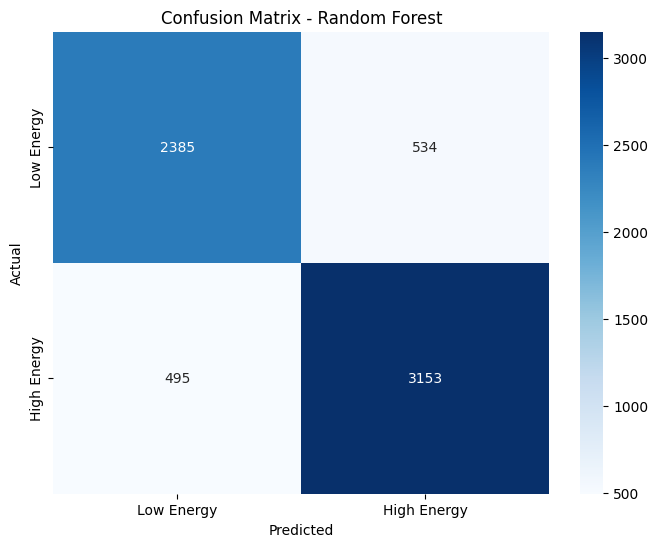

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Setting the threshold for high and low energy
df['energy_category'] = df['energy'] >= 0.7

# Select features and target variable
features = df[['loudness', 'speechiness', 'acousticness', 'tempo', 'valence']]
target = df['energy_category']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Min-Max Scaling for specific columns
min_max_scaler = MinMaxScaler()
columns_to_normalize = ['loudness', 'speechiness', 'acousticness', 'tempo']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[columns_to_normalize] = min_max_scaler.fit_transform(X_train[columns_to_normalize])
X_test_scaled[columns_to_normalize] = min_max_scaler.transform(X_test[columns_to_normalize])

# Create a Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
predictions = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)
classification_rep = classification_report(y_test, predictions)

# Print the results
print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_rep)

# Feature Importance Plot
feature_importance = pd.Series(rf_model.feature_importances_, index=features.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Confusion Matrix Plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Low Energy', 'High Energy'], yticklabels=['Low Energy', 'High Energy'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


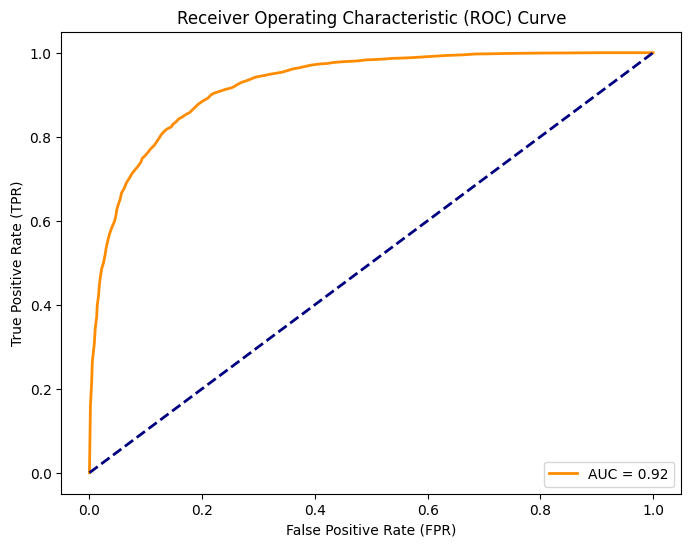

Area Under the ROC Curve (AUC): 0.92


In [11]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC (Area Under the Curve)
auc_score = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Print AUC score
print("Area Under the ROC Curve (AUC): {:.2f}".format(auc_score))



AUC = 0.92: This suggests that our Random Forest model has a very good ability to distinguish between the two classes (High Energy and Low Energy)